# imports

In [9]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from scipy.stats import bernoulli
import warnings
from plotter import *
from scipy.special import softmax
from scipy.spatial.distance import cdist
import gymnasium as gym
from gymnasium.envs.registration import register, registry, make, spec
import pickle
import copy
from itertools import product
import json
from functools import partial
from scipy.optimize import Bounds, minimize, differential_evolution
import multiprocess as mp
from pybads import BADS
import pymer4.models as pm

import IPython

import multiprocess as mp
import pingouin as pg
from scipy.special import expit

from emp_utils import *
from emp_runners import *


warnings.filterwarnings('ignore')


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
env = make_emp_env(n_arms=2, n_outcomes=3, n_trials=7, alpha=0.1, ell=1.0)
room_1 = [
    [1,0,0],
    [0,1,0]
    ]
room_2 = [
    [1,0,0],
    [0, 0.5,0.5],
    ]
ells = [0.5, 1.0, 2]
for ell in ells:
    for r, room in enumerate([room_1, room_2], start=1):
        print(f"Empowerment for ell={ell} in room {r}: {env.empowerment(room, ell)}")
    print('')

##

Empowerment for ell=0.5 in room 1: 2.0
Empowerment for ell=0.5 in room 2: 2.414213562373095

Empowerment for ell=1.0 in room 1: 2.0
Empowerment for ell=1.0 in room 2: 2.0

Empowerment for ell=2 in room 1: 2.0
Empowerment for ell=2 in room 2: 1.5



# Expts

## Interact with env

In [76]:
## make emp env
n_arms = 2
n_outcomes = 4
n_trials = 4
alpha = 0.1
ell = 1
policy = 'uniform_tail'
policy = 'bellman'
env = make_emp_env(n_arms, n_outcomes, n_trials, alpha, ell, seed = 1)

## make agent
agent = BAMCP(
    mcts_class=MonteCarloTreeSearch_Emp, run_fn=run_emp_bamcp,
    n_samples=100000,
    exploration_constant=3,
    discount_factor=1,
    horizon=1,
    temp=1,
    lapse=0,
)


run_emp_enum(agent, env, policy = policy)

NameError: name 'run_emp_enum' is not defined

## Enumerate histories

In [11]:
## inits
n_arms = 2
n_outcomes = 3
n_trials = 3
alpha = 0.1
temp = 0.1
ells = [0.1, 
        1.0, 
        10]

## run 
df = enumerate_emp_histories(
    n_arms=n_arms, n_outcomes=n_outcomes, n_trials=n_trials,
    alpha=alpha, termination_arm=True, ells=ells, temp=temp,
)

print(f"{len(df)} rows  ({len(ells)} ells x {len(df)//len(ells)} histories)")
df.loc[df['history_counts_str'].isna(), 'history_counts_str'] = '()'

## save df
df.to_csv('useful_saves/enum_histories_{}_arms_{}_outcomes_{}_trials_{}_alpha.csv'.format(n_arms, n_outcomes, n_trials, alpha), index=False)
df.head(70)

Tipping point for history a0o0:2: arms 0 and 2: 1.0000000000002673
Tipping point for history a0o0:2: arms 1 and 2: 1.0000000000002673
Tipping point for history a0o0:1-a0o1:1: arms 1 and 2: 0.27083828116874603

Tipping point for history a0o0:2: arms 0 and 2: 1.0000000000002673
Tipping point for history a0o0:2: arms 1 and 2: 1.0000000000002673
Tipping point for history a0o0:1-a0o1:1: arms 1 and 2: 0.27083828116874603

Tipping point for history a0o0:2: arms 0 and 2: 1.0000000000002673
Tipping point for history a0o0:2: arms 1 and 2: 1.0000000000002673
Tipping point for history a0o0:1-a0o1:1: arms 1 and 2: 0.27083828116874603

18 rows  (3 ells x 6 histories)


,ell,t,history,history_str,orbit_size,current_emp,p_choose_least_sampled,best_a,policy_entropy,chosen_prob,...,p_1,delta_emp_1,entropy_1,max_reach__0,max_reach__1,max_reach__2,Q_terminate,p_terminate,history_counts,history_counts_str
0,0.1,0,(),init,1,2.687875,0.415884,0,1.029609,0.415884,...,0.415884,8.747489e-02,-13.024983,0.333333,0.333333,0.333333,2.687875,0.168231,(),init
1,0.1,1,"(((0, 0), 1),)",a0o0:1,6,2.775350,0.169686,0,1.030822,0.421450,...,0.169686,-1.046161e-01,-13.024983,0.846154,0.333333,0.333333,2.775350,0.408864,"(((0, 0), 1),)",a0o0:1
2,0.1,2,"(((0, 0), 2),)",a0o0:2,6,2.782861,0.149704,2,1.011573,0.426163,...,0.149704,-1.046161e-01,-13.024983,0.913043,0.333333,0.333333,2.782861,0.426163,"(((0, 0), 2),)",a0o0:2
3,0.1,2,"(((0, 0), 1), ((0, 1), 1))",a0o0:1-a0o1:1,12,2.753748,0.307797,2,1.096482,0.361019,...,0.307797,-1.594896e-02,-13.024983,0.478261,0.478261,0.333333,2.753748,0.361019,"(((0, 0), 1), ((0, 1), 1))",a0o0:1-a0o1:1
4,0.1,2,"(((0, 0), 1), ((1, 0), 1))",a0o0:1-a1o0:1,6,2.530951,0.365074,1,1.089212,0.365074,...,0.365074,3.022227e-02,-13.869031,0.846154,0.076923,0.076923,2.530951,0.269853,"(((0, 0), 1), ((1, 0), 1))",a0o0:1-a1o0:1
5,0.1,2,"(((0, 0), 1), ((1, 1), 1))",a0o0:1-a1o1:1,12,2.740626,0.344144,0,1.097548,0.344144,...,0.344144,9.898187e-03,-13.869031,0.846154,0.846154,0.076923,2.740626,0.311712,"(((0, 0), 1), ((1, 1), 1))",a0o0:1-a1o1:1
6,1.0,0,(),init,1,1.000000,0.499188,0,0.704071,0.499188,...,0.499188,5.128205e-01,-13.024983,0.333333,0.333333,0.333333,1.000000,0.001623,(),init
7,1.0,1,"(((0, 0), 1),)",a0o0:1,6,1.512821,0.392364,0,1.064790,0.392364,...,0.392364,0.000000e+00,-13.024983,0.846154,0.333333,0.333333,1.512821,0.215271,"(((0, 0), 1),)",a0o0:1
8,1.0,2,"(((0, 0), 2),)",a0o0:2,6,1.579710,0.333333,2,1.098612,0.333333,...,0.333333,-2.220446e-16,-13.024983,0.913043,0.333333,0.333333,1.579710,0.333333,"(((0, 0), 2),)",a0o0:2
9,1.0,2,"(((0, 0), 1), ((0, 1), 1))",a0o0:1-a0o1:1,12,1.289855,0.853144,1,0.519010,0.853144,...,0.853144,2.452620e-01,-13.024983,0.478261,0.478261,0.333333,1.289855,0.073428,"(((0, 0), 1), ((0, 1), 1))",a0o0:1-a0o1:1


In [53]:
df[['ell','t','history_str','p_0','p_1','p_terminate','best_a']].head(20)

,ell,t,history_str,p_0,p_1,p_terminate,best_a
0,0.1,0,init,0.432729,0.432729,0.134542,1
1,0.1,1,a0o0:1,0.456940,0.134543,0.408517,0
2,0.1,2,a0o0:2,0.448839,0.114833,0.436327,0
3,0.1,2,a0o0:1-a0o1:1,0.390473,0.201241,0.408286,2
4,0.1,2,a0o0:1-a1o0:1,0.396372,0.396372,0.207257,0
5,0.1,2,a0o0:1-a1o1:1,0.367005,0.367005,0.265989,0
6,0.1,3,a0o0:3,0.448714,0.105034,0.446252,0
7,0.1,3,a0o0:2-a0o1:1,0.405904,0.193515,0.400581,0
8,0.1,3,a0o0:2-a1o0:1,0.454529,0.197327,0.348144,0
9,0.1,3,a0o0:2-a1o1:1,0.413118,0.231363,0.355518,0


In [3]:
n_arms = 2
n_outcomes = 4
n_trials = 8
alpha = 0.1
temp = 0.1
ells = [0.1, 
        1.0, 
        10]

## load df
df = pd.read_csv('useful_saves/emp/enum_histories_{}_arms_{}_outcomes_{}_trials_{}_alpha.csv'.format(n_arms, n_outcomes, n_trials, alpha))

KeyboardInterrupt: 

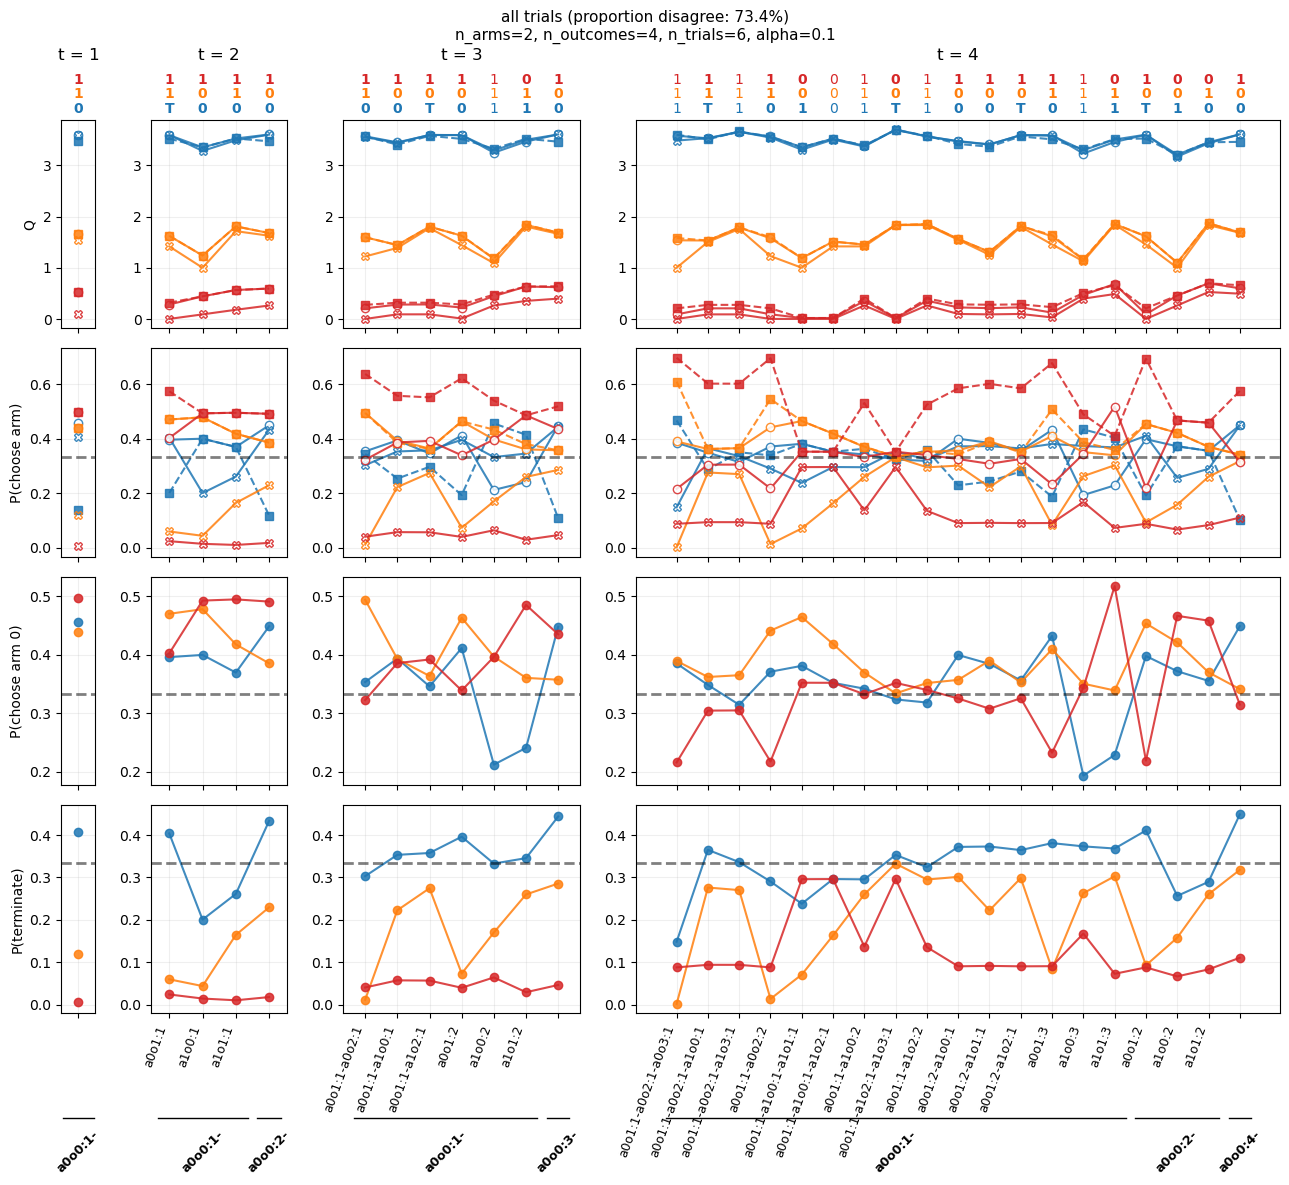

In [61]:
## preprocess: add 'history_canon_counts_str' and 'disagree' columns
df_cleaned = filter_histories(df, canonicalize=True)
disagree_only = False
proportion_disagree = df_cleaned.groupby(['t', 'history_canon_counts_str'])['disagree'].mean().mean()
if disagree_only:
    title = 'disagree trials (proportion of total: {:.1%})\nn_arms={}, n_outcomes={}, n_trials={}, alpha={}'.format(proportion_disagree, n_arms, n_outcomes, n_trials, alpha)
else:
    title = 'all trials (proportion disagree: {:.1%})\nn_arms={}, n_outcomes={}, n_trials={}, alpha={}'.format(proportion_disagree, n_arms, n_outcomes, n_trials, alpha)

## plot
plot_history_panels(
    df_cleaned,
    ells=ells,
    n_arms=n_arms,
    canonicalize=True,
    n_plot_trials=5,
    disagree_only=disagree_only,
    group_brackets=True,
    skip_t0=True,
    legend=False,
    suptitle=f'{title}',
)
plt.show()

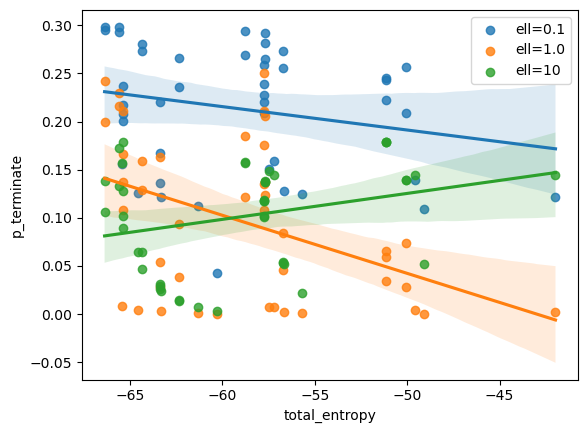

In [4]:
## entropy plots
plt.figure()
for ell in ells:
    sns.regplot(
              # x='chosen_entropy', 
              #   y='chosen_prob',
              x='total_entropy', 
                y='p_terminate',
                  data=df_cleaned.loc[df_cleaned['ell'] == ell], label=f'ell={ell}')
plt.legend()



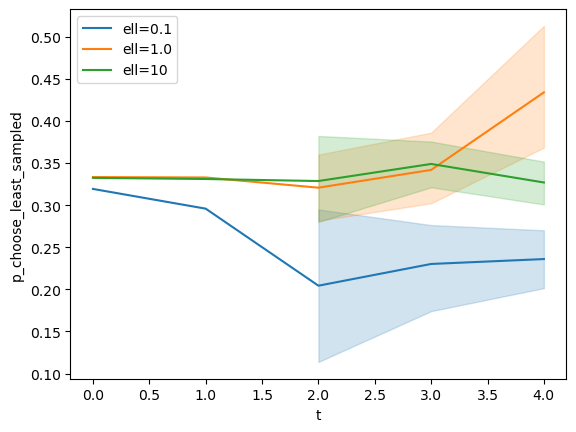

In [6]:
for ell in ells:
    sns.lineplot(data = df_cleaned.loc[df_cleaned['ell'] == ell], x='t', 
                 y='p_terminate', 
                #  y='p_choose_least_sampled', 
                 label=f'ell={ell}', palette = 'Set1')

,t,history_canon_counts_str,best_a,canon_p_0,canon_p_1,p_terminate,p_choose_least_sampled,current_emp,max_delta_emp,total_entropy,n_untried_arms,n_unobserved_outcomes
129,4,a0o0:1-a0o1:1-a1o2:1-a1o3:1,2,0.191511,0.191511,0.179276,0.437701,0.001636,0.089261,-51.158018,1,0
125,4,a0o0:1-a0o1:1-a1o0:1-a1o2:1,2,0.191681,0.191681,0.179049,0.437589,0.001228,0.089362,-51.158018,1,1
124,4,a0o0:1-a0o1:1-a1o0:1-a1o1:1,2,0.191850,0.191850,0.178822,0.437477,0.000820,0.089463,-51.158018,1,2
115,4,a0o0:1-a1o0:1-a2o0:2,0,0.178682,0.178682,0.178525,0.178682,0.263076,0.095540,-65.364503,0,3
106,4,a0o0:1-a1o0:3,2,0.172629,0.316988,0.172478,0.337905,0.397037,0.067250,-65.556545,1,3
114,4,a0o0:1-a0o1:1-a1o0:2,0,0.163067,0.370385,0.157770,0.308778,0.263487,0.085340,-58.760123,1,2
104,4,a0o0:4,1,0.227319,0.307789,0.157103,0.307789,0.493531,0.067252,-65.399306,2,3
118,4,a0o0:1-a0o1:1-a1o2:2,0,0.167674,0.368483,0.156961,0.306883,0.263895,0.085340,-58.760123,1,1
105,4,a0o0:1-a0o1:3,1,0.174450,0.338363,0.148825,0.338363,0.030139,0.082135,-57.448012,2,2
121,4,a0o0:1-a0o1:1-a0o2:1-a0o3:1,1,0.144963,0.355094,0.144849,0.355094,0.000004,0.089669,-41.981338,2,0


28


<Axes: xlabel='current_emp', ylabel='p_terminate'>

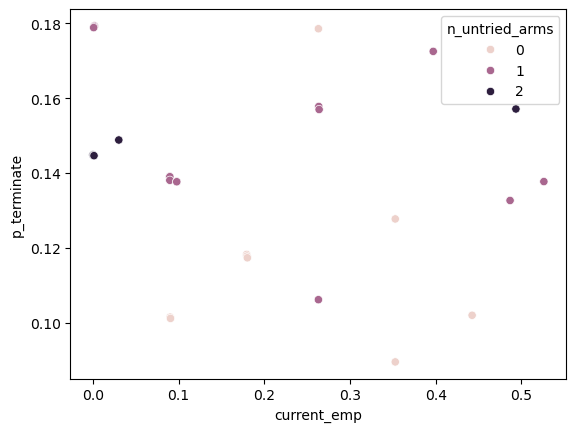

In [11]:
## analyse when certaintist wants to terminate
tmp = df_cleaned.loc[(df_cleaned['ell']==10) 
               &(df_cleaned['t']==n_trials-1)
            #    &(df_cleaned['p_terminate']>0.33)
]
               # ,['t','history_canon_counts_str','canon_p_0','canon_p_1','p_terminate', 'current_emp', 'total_entropy']].groupby('history_canon_counts_str').first()

## order tmp by p_terminate
tmp = tmp.sort_values('p_terminate', 
                      # ascending=True
                      ascending=False
                      )
display(tmp[
    ['t','history_canon_counts_str','best_a','canon_p_0','canon_p_1','p_terminate', 'p_choose_least_sampled','current_emp','max_delta_emp', 'total_entropy', 'n_untried_arms', 'n_unobserved_outcomes']
].head(50))
print(len(tmp))

## scatter of current_emp and p_terminate
plt.figure()
hue = 'n_untried_arms'
# hue = 'n_unobserved_outcomes'

sns.scatterplot(data=tmp, 
                x='current_emp', 
                y='p_terminate',
                # y='p_choose_least_sampled',

                # style='n_untried_arms',
                # hue = 'n_unobserved_outcomes',

                  hue = hue
                  )

,t,history_canon_counts_str,canon_p_0,canon_p_1,p_terminate,p_choose_least_sampled,current_emp,max_delta_emp,total_entropy,n_untried_arms,n_unobserved_outcomes
334,6,a0o0:1-a0o1:4-a1o1:1,0.190950,0.636816,0.172234,0.636816,0.089670,0.130763,-39.011436,0,2
347,6,a0o0:1-a0o1:1-a0o2:3-a1o2:1,0.190382,0.619247,0.190371,0.619247,0.089670,0.117953,-31.060142,0,1
343,6,a0o0:1-a1o0:3-a1o1:2,0.618998,0.190698,0.190305,0.618998,0.089749,0.117947,-38.662247,0,2
374,6,a0o0:1-a0o1:1-a0o2:1-a0o3:2-a1o3:1,0.191266,0.617485,0.191249,0.617485,0.089670,0.117208,-23.195574,0,0
366,6,a0o0:1-a0o1:2-a0o2:2-a1o1:1,0.191583,0.617235,0.191183,0.617235,0.089749,0.117202,-30.797679,0,1
375,6,a0o0:1-a0o1:1-a0o2:1-a0o3:2-a1o0:1,0.191587,0.617231,0.191182,0.617231,0.089749,0.117202,-23.195574,0,0
367,6,a0o0:1-a0o1:2-a0o2:2-a1o0:1,0.191904,0.616981,0.191115,0.616981,0.089828,0.117196,-30.797679,0,1
368,6,a0o0:1-a0o1:2-a0o2:2-a1o3:1,0.191909,0.616977,0.191114,0.616977,0.089828,0.117196,-30.797679,0,0
331,6,a0o0:1-a1o1:5,0.584983,0.233781,0.181236,0.584983,0.654300,0.117178,-47.005726,0,2
335,6,a0o0:1-a0o1:4-a1o0:1,0.219885,0.595592,0.184523,0.595592,0.153335,0.117178,-39.011436,0,2


68


<Axes: xlabel='current_emp', ylabel='max_delta_emp'>

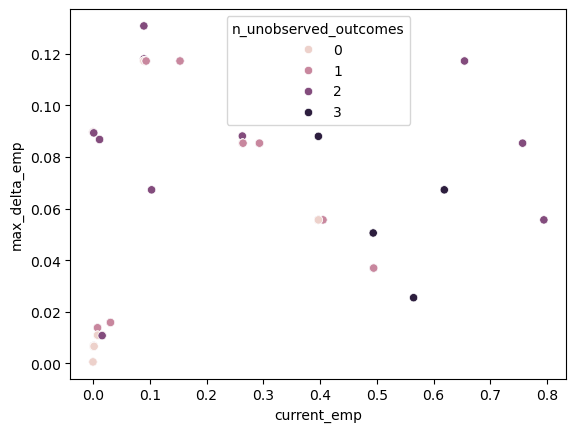

In [164]:
## find the cases where the certaintist has the highest expected gain in empowerment
tmp = df_cleaned.loc[
    (df_cleaned['ell']==10) 
               &(df_cleaned['t']==6)
]

## order tmp by max_delta_emp
tmp = tmp.sort_values('max_delta_emp', 
                    #   ascending=True
                      ascending=False
                      )
display(tmp[
    ['t','history_canon_counts_str','canon_p_0','canon_p_1','p_terminate', 'p_choose_least_sampled','current_emp','max_delta_emp', 'total_entropy', 'n_untried_arms', 'n_unobserved_outcomes']
].head(50))
print(len(tmp))

## scatter of current_emp and p_terminate
plt.figure()
# hue = 'n_untried_arms'
# # hue = 'n_unobserved_outcomes'
# sns.swarmplot(data=tmp,x = 'n_untried_arms', y = 'max_delta_emp', hue = 'n_unobserved_outcomes')

sns.scatterplot(data=tmp, 
                # x='max_delta_emp', 
                # y='p_terminate',
                x='current_emp', 
                y='max_delta_emp',
                # y='p_choose_least_sampled',

                # style='n_untried_arms',
                # hue = 'n_unobserved_outcomes',

                  hue = hue
                  )

## Misc

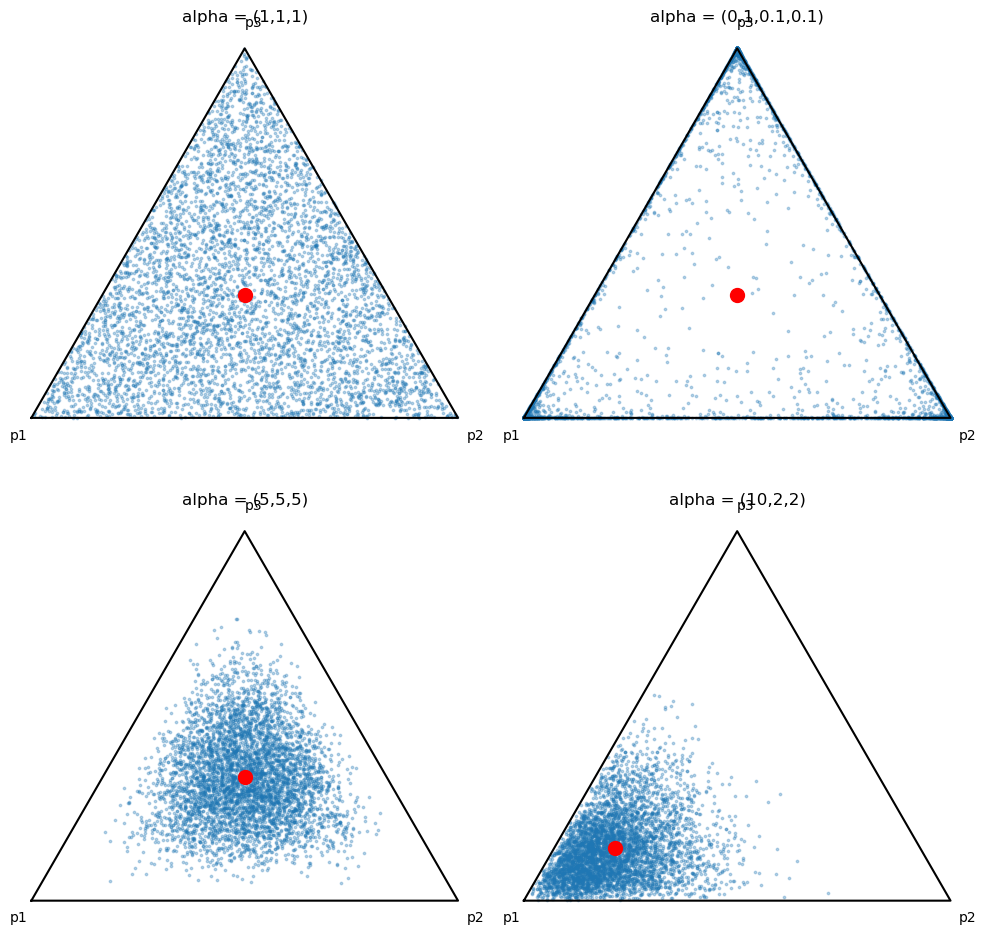

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Simplex projection utilities
# -----------------------------

def simplex_to_2d(p):
    """
    Convert 3D simplex coordinates (p1,p2,p3)
    into 2D Cartesian coordinates.
    """
    v1 = np.array([0, 0])
    v2 = np.array([1, 0])
    v3 = np.array([0.5, np.sqrt(3)/2])

    return (
        p[:, 0][:, None] * v1
        + p[:, 1][:, None] * v2
        + p[:, 2][:, None] * v3
    )

def draw_simplex(ax):
    triangle = np.array([
        [0, 0],
        [1, 0],
        [0.5, np.sqrt(3)/2],
        [0, 0]
    ])

    ax.plot(triangle[:, 0], triangle[:, 1], 'k-')

    ax.text(-0.05, -0.05, "p1")
    ax.text(1.02, -0.05, "p2")
    ax.text(0.5, np.sqrt(3)/2 + 0.05, "p3")

    ax.set_aspect('equal')
    ax.axis('off')

# -----------------------------
# Dirichlet priors to compare
# -----------------------------

priors = [
    ([1, 1, 1], "alpha = (1,1,1)"),
    ([0.1, 0.1, 0.1], "alpha = (0.1,0.1,0.1)"),
    ([5, 5, 5], "alpha = (5,5,5)"),
    ([10, 2, 2], "alpha = (10,2,2)")
]

# -----------------------------
# Plot
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (alpha, title) in zip(axes.flatten(), priors):

    samples = np.random.dirichlet(alpha, size=5000)
    xy = simplex_to_2d(samples)

    draw_simplex(ax)

    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        s=3,
        alpha=0.3
    )

    ## plot mean
    mean = np.array(alpha) / np.sum(alpha)
    mean_xy = simplex_to_2d(mean[None, :])
    ax.scatter(
        mean_xy[:, 0],
        mean_xy[:, 1],
        s=100,
        color='red',
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()

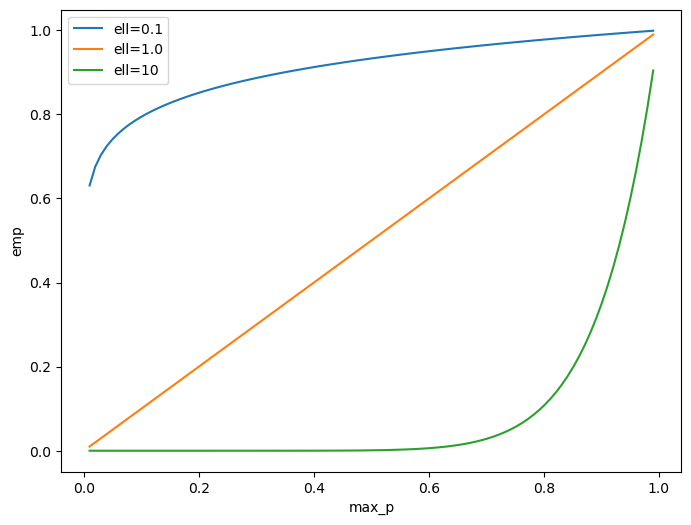

In [16]:
ells = [0.1, 1.0, 10]
x = np.linspace(0.01, 0.99, 100)
plt.figure(figsize=(8, 6))
for ell in ells:
    plt.plot(x, x**ell, label=f'ell={ell}')
plt.xlabel('max_p')
plt.ylabel('emp')
plt.legend()

a0 init: 0, Prior mean: [0.33333333 0.33333333 0.33333333]
Shift in all means after observing outcome 0: [ 0.16666667 -0.08333333 -0.08333333]
Shift in all means after observing outcome 1: [-0.08333333  0.16666667 -0.08333333]
Shift in all means after observing outcome 2: [-0.08333333 -0.08333333  0.16666667]

a0 init: 1, Prior mean: [0.5  0.25 0.25]
Shift in all means after observing outcome 0: [ 0.1  -0.05 -0.05]
Shift in all means after observing outcome 1: [-0.1   0.15 -0.05]
Shift in all means after observing outcome 2: [-0.1  -0.05  0.15]

a0 init: 2, Prior mean: [0.6 0.2 0.2]
Shift in all means after observing outcome 0: [ 0.06666667 -0.03333333 -0.03333333]
Shift in all means after observing outcome 1: [-0.1         0.13333333 -0.03333333]
Shift in all means after observing outcome 2: [-0.1        -0.03333333  0.13333333]

a0 init: 3, Prior mean: [0.66666667 0.16666667 0.16666667]
Shift in all means after observing outcome 0: [ 0.04761905 -0.02380952 -0.02380952]
Shift in all m

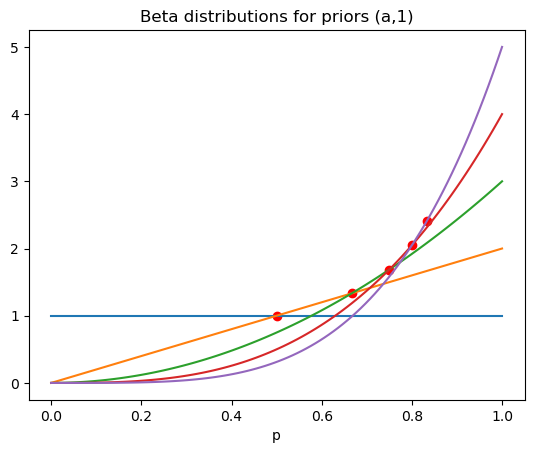

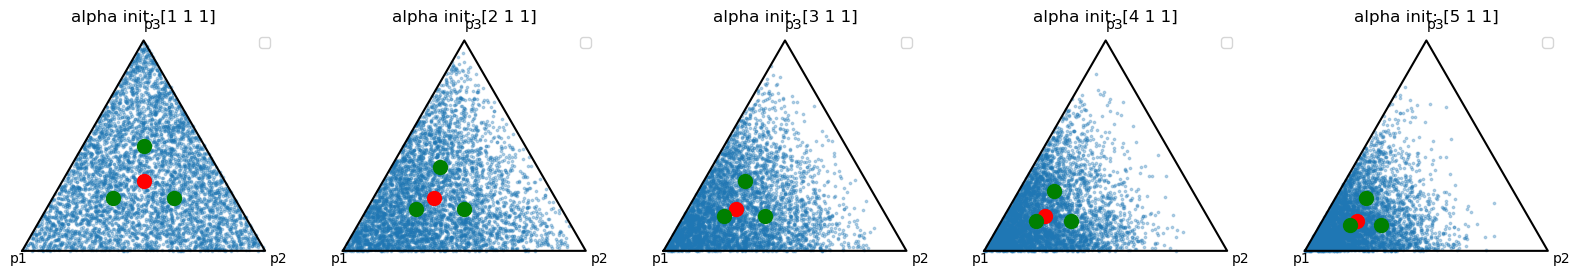

In [48]:
## plot beta distributions for priors (a,1) where a increments from 1 to 5
plt.figure()
for a in range(1, 6):
    x = np.linspace(0, 1, 100)
    y = stats.beta.pdf(x, a, 1)
    plt.plot(x, y, label=f'a={a}')
    mean = a / (a + 1)
    plt.scatter(mean, stats.beta.pdf(mean, a, 1), label=f'mean a={a}', color='red')
plt.title('Beta distributions for priors (a,1)')
plt.xlabel('p')

## now, let's loop through dirichlet priors (a,1,1) where a increments from 1 to 5
# for a in range(1, 6):
#     alpha = [a, 1, 1]
#     samples = np.random.dirichlet(alpha, size=5000)
#     xy = simplex_to_2d(samples)

#     plt.figure()
#     draw_simplex(plt.gca())
#     plt.scatter(
#         xy[:, 0],
#         xy[:, 1],
#         s=3,
#         alpha=0.3
#     )

#     ## plot mean
#     mean = np.array(alpha) / np.sum(alpha)
#     mean_xy = simplex_to_2d(mean[None, :])
#     plt.scatter(
#         mean_xy[:, 0],
#         mean_xy[:, 1],
#         s=100,
#         color='red',
#     )

#     plt.title(f'Dirichlet samples for alpha={alpha}')


## for dirichlet prior (5,1,1), calculate the shift in posterior mean after observing one sample of each outcome (i.e., adding 1 to each alpha)
n_a0_inits = 5
a = 1

fig, axs = plt.subplots(1, n_a0_inits, figsize=(20, 4))
for a0_init in range(0, n_a0_inits):
    alpha = np.array([a0_init+a, a, a])
    mean_prior = alpha / np.sum(alpha)
    print(f"a0 init: {a0_init}, Prior mean: {mean_prior}")
    samples = np.random.dirichlet(alpha, size=5000)
    xy = simplex_to_2d(samples)
    draw_simplex(axs[a0_init])
    axs[a0_init].scatter(
        xy[:, 0],
        xy[:, 1],
        s=3,
        alpha=0.3
    )
    #mean
    mean_xy = simplex_to_2d(mean_prior[None, :])
    axs[a0_init].scatter(
        mean_xy[:, 0],
        mean_xy[:, 1],
        s=100,
        color='red',
    )
    axs[a0_init].set_title(f"alpha init: {alpha}")
    for k in range(3):
        alpha_post = alpha + np.eye(3)[k]  # add one sample to the k-th outcome
        mean_post = alpha_post / np.sum(alpha_post)
        # print(f"Posterior mean over: {mean_post} after observing outcome {k+1}")
        # print('Shift in mean over outcomes: {:.3f}'.format(mean_post[0] - mean_prior[0]))
        mean_shifts = mean_post - mean_prior
        print('Shift in all means after observing outcome {}: {}'.format(k, mean_shifts))
        # print('Shift in mean over outcomes: {:.3f}'.format(np.linalg.norm(mean_post - mean_prior)))
        samples_post = np.random.dirichlet(alpha_post, size=5000)
        # xy_post = simplex_to_2d(samples_post)
        # axs[a0_init].scatter(
        #     xy_post[:, 0],
        #     xy_post[:, 1],
        #     s=3,
        #     alpha=0.2,
        #     # label=f'obs outcome {k+1}'
        # )
        # plot mean of posterior
        mean_post_xy = simplex_to_2d(mean_post[None, :])
        axs[a0_init].scatter(
            mean_post_xy[:, 0],
            mean_post_xy[:, 1],
            s=100,
            color='green',
            # label=f'mean post obs outcome {k+1}'
        )
    axs[a0_init].legend()
    print()
